In [76]:
from typing import Literal, Dict, List, TypedDict

import shared_libraries.simulation as sim
import shared_libraries._simulation_utils as _simutils

import pandas as pd
import numpy as np
import pickle

import statistics
import random

import matplotlib.pyplot as plt

In [2]:
with open("ig_models/models.pickle", "rb") as file:
    models = pickle.load(file)

In [3]:
circuit_lap_counts = pd.read_csv("./ig_data/circuit_lap_counts.csv", index_col=0)
circuit_lap_counts

,LapCount
Sakhir,57
Jeddah,50
Melbourne,58
Miami,57
Catalunya,66
Monte Carlo,78
Baku,51
Montreal,70
Silverstone,52
Paul Ricard,53


In [4]:
compound_mappings = sim.prepare_example_compound_mappings()
weathers = sim.prepare_example_weather_data()
simulation_results = sim.prepare_simulation(
    ["Austin", "Spielberg"],
    compound_mappings,
    weathers,
    circuit_lap_counts
)

In [5]:
simulation_results["WeatherAndMappingCombinations"]

,Id,WeatherName,CompoundMappingName
0,0,Desert,Fast
1,1,Desert,Medium
2,2,Desert,Durable
3,3,Tropical,Fast
4,4,Tropical,Medium
5,5,Tropical,Durable
6,6,Temperate,Fast
7,7,Temperate,Medium
8,8,Temperate,Durable
9,9,Desert,Fast


In [6]:
simulation_results["FullStrategyData"]["Austin"][0]["Laps"]

,StrategyId,LapNumber,TyreLife,IsPitLap,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindSpeed,...,RealCompound_C3,RealCompound_C4,RealCompound_C5,WindDirection_N,WindDirection_NE,WindDirection_E,WindDirection_SE,WindDirection_S,WindDirection_SW,WindDirection_W
0,0,1,1,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
1,0,2,2,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
2,0,3,3,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
3,0,4,4,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
4,0,5,5,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40035,714,52,23,False,33,28,1009,False,42,8,...,True,False,False,False,False,False,False,False,False,False
40036,714,53,24,False,33,28,1009,False,42,8,...,True,False,False,False,False,False,False,False,False,False
40037,714,54,25,False,33,28,1009,False,42,8,...,True,False,False,False,False,False,False,False,False,False
40038,714,55,26,False,33,28,1009,False,42,8,...,True,False,False,False,False,False,False,False,False,False


In [ ]:


for circuit, strategy_data_by_conditions in simulation_results["FullStrategyData"].items():
    model = models[circuit]["XGBRegressor"].best_estimator_
    for conditions_id, strategy_data in strategy_data_by_conditions.items():

        strategy_data_post_evaluation = _simutils.evaluate_strategies(strategy_data, model)
        
        laps = strategy_data_post_evaluation["Laps"]
        strategies = strategy_data_post_evaluation["Strategies"]
        conditions = simulation_results["WeatherAndMappingCombinations"].loc[conditions_id]
        mapping_name: str = conditions["WeatherName"] # type: ignore
        weather_name: str = conditions["CompoundMappingName"] # type: ignore

        best_strat_id = strategies.sort_values(by="MeanZScore", axis="index", ascending=False).iloc[0]["Id"]
        strat = strategies.loc[best_strat_id, "Strategy"]

        path = f"./figures/simulation_results/{circuit}/{weather_name.replace(' ', '_')}__{mapping_name.replace(' ', '_')}"
        fig, ax = plt.subplots()
        ax.plot()
        break
    break
        


In [54]:



strategies[strategies["Id"] == best_strat_id]
strat: _simutils.__Strategy = strategies.loc[best_strat_id, "Strategy"] # type: ignore
strat

Strategy[['SOFT', 'SOFT', 'HARD'], [15, 41]]

In [70]:
best_strat_laps = laps[laps["StrategyId"] == best_strat_id]
race_length = best_strat_laps.shape[0]
stints = []
current_compound = strat.initial_compound
current_lap = 1
for pit_lap, compound in strat.stops.items():
    start = current_lap
    while current_lap < pit_lap:
        current_lap += 1
    stints.append({"start": start, "end": current_lap, "compound": current_compound})
    current_lap += 1
    current_compound = compound
stints.append({"start": current_lap, "end": race_length, "compound": current_compound})


In [71]:
stints

[{'start': 1, 'end': 15, 'compound': 'SOFT'},
 {'start': 16, 'end': 41, 'compound': 'SOFT'},
 {'start': 42, 'end': 56, 'compound': 'HARD'}]

1 15
16 41
42 56


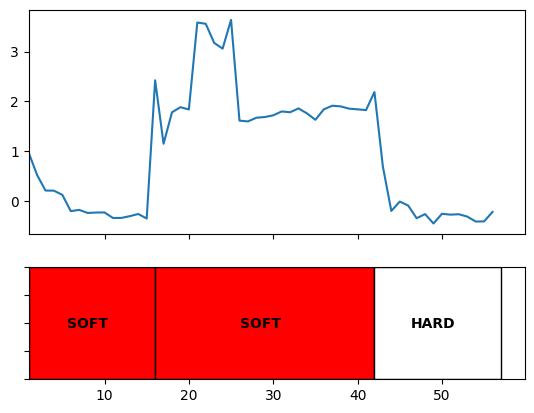

In [88]:



fig, (chart_ax, stint_ax) = plt.subplots(2, 1, height_ratios=(2, 1), sharex=True)
chart_ax.plot(best_strat_laps["LapNumber"], best_strat_laps["LapTimeZScore"])

compound_colors = {"SOFT": "red", "MEDIUM": "yellow", "HARD": "white"}
for stint in stints:
    compound = stint["compound"]
    stint_length = stint["end"] - stint["start"] + 1

    color = compound_colors.get(
        stint["compound"], "grey"
    )

    stint_ax.margins(0, 0)
    stint_ax.set_yticklabels([])
    stint_ax.barh(0, width=stint_length, height=1, left=stint["start"], color=color, edgecolor="black")
    print(stint["start"], stint["end"])
    stint_ax.text(np.mean([stint["start"], stint["end"]]), 0, compound, va="center", ha="center", fontweight="bold")



In [9]:
laps

,StrategyId,LapNumber,TyreLife,IsPitLap,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindSpeed,...,RealCompound_C4,RealCompound_C5,WindDirection_N,WindDirection_NE,WindDirection_E,WindDirection_SE,WindDirection_S,WindDirection_SW,WindDirection_W,LapTimeZScore
0,0,1,1,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,0.976197
1,0,2,2,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,0.525473
2,0,3,3,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,0.211090
3,0,4,4,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,0.208286
4,0,5,5,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,0.124138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40035,714,52,23,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,-0.254610
40036,714,53,24,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,-0.275860
40037,714,54,25,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,-0.290327
40038,714,55,26,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,-0.317525
